## **Differential Operators: Calculations Using SymPy**

We deal with the concept of a field when a function will be defined on the points of some space. If it will be a scalar function then we are dealing with a scalar field. On the other hand, if we assign a vector to the field, we get a vector field. An example of a scalar field is the air temperature, while an example of a vector field is the gravitational force field.

Differential operators can operate on both functions of one and many variables, on either scalar or vector functions. Basic differential operators include gradient, divergence and rotation. Using differential operators, new functions are created that convey a lot of additional information about the original function.

In [1]:
from IPython.display import HTML
HTML('<div align="center"><iframe width="560" height="315" src="https://www.youtube.com/embed/rB83DpBJQsE?si=lmN4iI6ev1ltMSCX" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" allowfullscreen></iframe></div>')

Differential calculations can be implemented using the SymPy library. SymPy is a Python library for symbolic mathematics. It aims to be an alternative to systems such as Mathematica or Maple while keeping the code as simple as possible and easily extensible. SymPy is written entirely in Python and does not require any external libraries.

> Source: https://el.us.edu.pl/ekonofizyka/index.php/Operatory_r%C3%B3%C5%BCniczkowe

## **Let's start!**

One more short message at the beginning:

*Below I have defined a number of functions whose purpose is to calculate particular differential operators for given scalar or vector functions and visualize the results obtained. The most important goal for me was to create a simple and clear visualization - one that will make it easier to understand what differential operators can be used for in the sciences.*

*This notebook was inspired by DoVan's work - https://www.kaggle.com/code/nhan1212/vector-field. However, I was keen not to be limited to predefined functions. For this reason, the following functions are written to take a user-defined scalar or vector function as an argument.*

In [2]:
# Import the necessary libraries
import numpy as np
import matplotlib.colors as clr
import matplotlib.pyplot as plt
from sympy import *
import warnings
warnings.filterwarnings('ignore')

---
### **Gradient**

In a nutshell: The gradient of a vector or scalar quantity means the decrease or increase of that quantity in a certain direction.

$\operatorname{grad}f(x,y,z)
= \begin{bmatrix} \frac{\partial}{\partial x} \\ \frac{\partial}{\partial y} \\ \frac{\partial}{\partial z} \end{bmatrix}  f(x,y,z)$

$\operatorname{grad}f(x,y,z)
= \begin{bmatrix} \frac{\partial f(x,y,z)}{\partial x} \\ \frac{\partial f(x,y,z)}{\partial y} \\ \frac{\partial f(x,y,z)}{\partial z}\end{bmatrix}$

In [3]:
def gradient_plot(scalar_field):
    
    # Definition of variables for SymPy library functions
    x, y = symbols('x y')
    
    # Calculation of the gradient of the scalar field f(x, y)
    f = sympify(scalar_field)
    gradf = [diff(f, x), diff(f, y)]
    
    # Determine the size of the chart and add titles
    plt.figure(figsize = (12, 8))
    plt.title(r'f(x, y) = ' + f'${latex(f)}$', loc = 'left')
    plt.title(r'$\longrightarrow$', loc = 'center')
    plt.title(r'$\operatorname{grad}f(x,y) = $' + f'$[{latex(gradf[0])}, {latex(gradf[1])}]$', loc = 'right')
    
    # Create a function based on SymPy mathematical formulas
    f = lambdify([x, y], f)
    gradf = [lambdify([x, y], gradf[0]), lambdify([x, y], gradf[1])]
    
    # Define a grid to visualize the scalar field f(x, y)
    scalar_density = 100
    dx_mesh, dy_mesh = np.meshgrid(np.linspace(-5, 5, scalar_density), 
                                   np.linspace(-5, 5, scalar_density))
    
    # Visualization of the scalar field f(x, y)
    try:
        f_max = np.array(f(dx_mesh, dy_mesh)).max()
        f_min = np.array(f(dx_mesh, dy_mesh)).min()
        plt.pcolormesh(dx_mesh, dy_mesh, f(dx_mesh, dy_mesh), 
                       cmap = 'RdBu', 
                       norm = clr.TwoSlopeNorm(vmin = f_min, 
                                               vcenter = 0.00, 
                                               vmax = f_max))
    except:
        f_const = np.full((scalar_density, scalar_density), f(dx_mesh, dy_mesh))
        plt.pcolormesh(dx_mesh, dy_mesh, f_const, 
                       cmap = 'RdBu', 
                       norm = clr.TwoSlopeNorm(vcenter = 0.00))
    
    plt.colorbar(location='left').set_label('The range of values that the scalar field takes for the given function', rotation = 90)
    
    # Define a grid to visualize the vector gradf
    vector_density = 25
    dx_mesh, dy_mesh = np.meshgrid(np.linspace(-5, 5, vector_density), 
                                   np.linspace(-5, 5, vector_density))
    
    # Visualization of the vector field gradf
    plt.quiver(dx_mesh, dy_mesh, gradf[0](dx_mesh, dy_mesh), gradf[1](dx_mesh, dy_mesh))
    
    # Add other chart parameters
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.xlabel('x')
    plt.ylabel('y')
    
    # Chart display
    return plt.show()

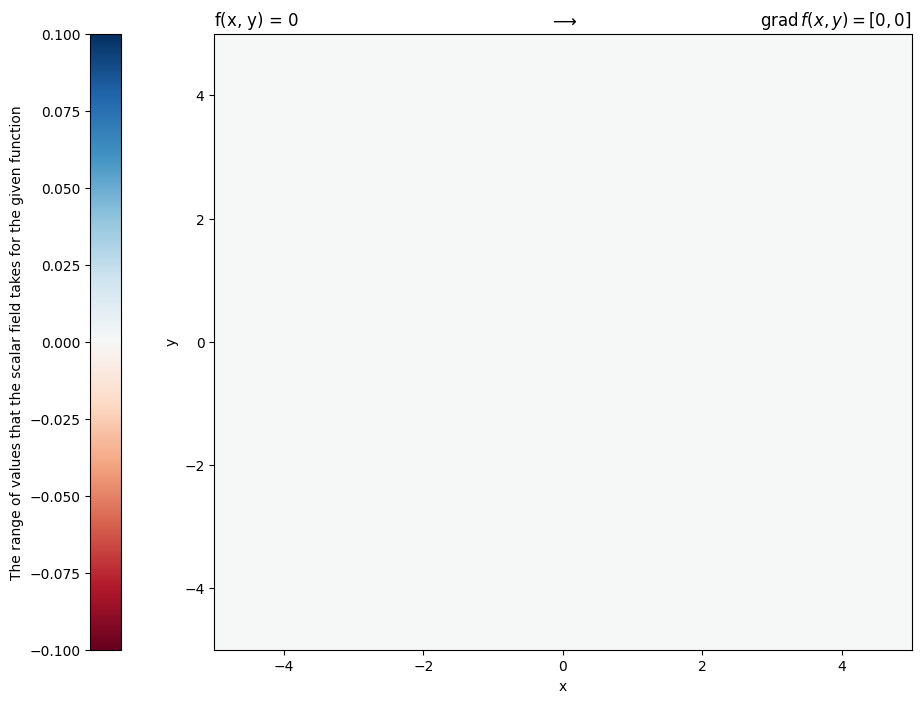

In [4]:
f = '0'
gradient_plot(f)

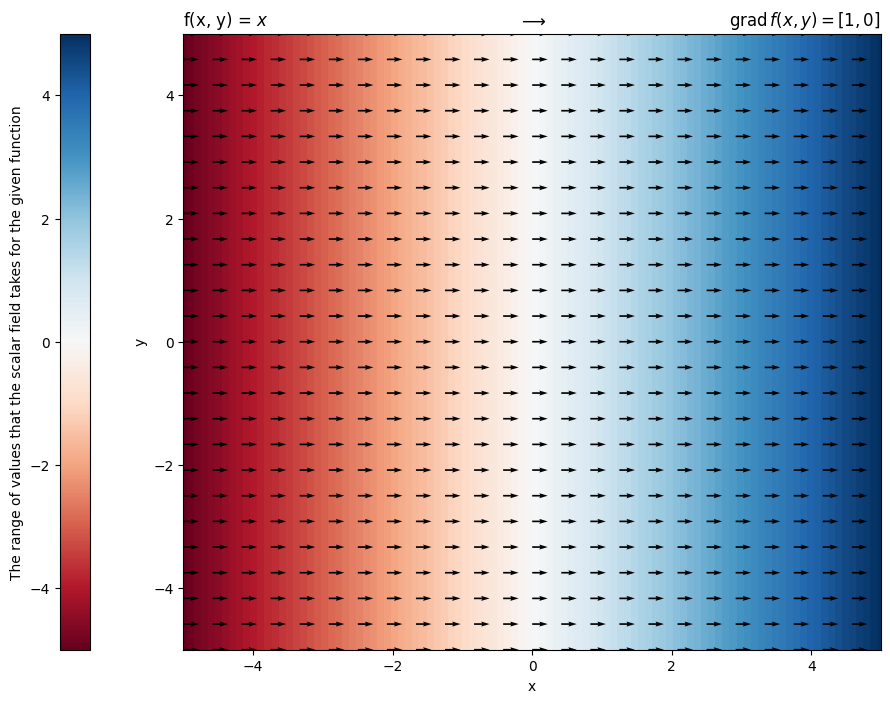

In [5]:
f = 'x'
gradient_plot(f)

---
### **Divergence**

In a nutshell: If the divergence is positive, then we are dealing with the "escape of a physical quantity from the system." We are then dealing with the source of that quantity. When the divergence is negative, we are dealing with the "influx of a physical quantity into the system."

$\operatorname{div}\mathbf{F}(x,y,z)
= \begin{bmatrix} \frac{\partial}{\partial x} \\ \frac{\partial}{\partial y} \\ \frac{\partial}{\partial z}\end{bmatrix} \cdot \mathbf{F}(x,y,z)$

$\operatorname{div}\mathbf{F}(x,y,z)
= \begin{bmatrix} \frac{\partial}{\partial x} \\ \frac{\partial}{\partial y} \\ \frac{\partial}{\partial z}\end{bmatrix} \cdot \begin{bmatrix}F_x(x,y,z) \\ F_y(x,y,z) \\ F_z(x,y,z)\end{bmatrix}$

$\operatorname{div}\mathbf{F}(x,y,z) = \frac{\partial F_x(x,y,z)}{\partial x} + \frac{\partial F_y(x,y,z)}{\partial y} + \frac{\partial F_z(x,y,z)}{\partial z}$

In [6]:
def divergence_plot(vector_field):
    
    # Definition of variables for SymPy library functions
    x, y = symbols('x y')
    
    # Calculation of the divergence of the vector field F(x, y)
    Fx = sympify(vector_field[0])
    Fy = sympify(vector_field[1])
    divF = diff(Fx, x) + diff(Fy, y)

    # Determine the size of the chart and add titles
    plt.figure(figsize = (12, 8))
    plt.title(r'$\mathbf{F}(x,y) = $' + f'$[{latex(Fx)}, {latex(Fy)}]$', loc = 'left')
    plt.title(r'$\longrightarrow$', loc = 'center')
    plt.title(r'$\operatorname{div}\mathbf{F}(x,y) = $' + f'${latex(divF)}$', loc = 'right')
    
    # Create a function based on SymPy mathematical formulas
    Fx = lambdify([x, y], Fx)
    Fy = lambdify([x, y], Fy)
    divF = lambdify([x, y], divF)
    
    # Define a grid to visualize the scalar field divF(x, y)
    scalar_density = 100
    dx_mesh, dy_mesh = np.meshgrid(np.linspace(-5, 5, scalar_density), 
                                   np.linspace(-5, 5, scalar_density))    
    
    # Visualization of the scalar field divF(x, y)
    try:
        divF_max = np.array(divF(dx_mesh, dy_mesh)).max()
        divF_min = np.array(divF(dx_mesh, dy_mesh)).min()
        plt.pcolormesh(dx_mesh, dy_mesh, divF(dx_mesh, dy_mesh), 
                       cmap = 'RdBu', 
                       norm = clr.TwoSlopeNorm(vmin = divF_min, 
                                               vcenter = 0.00, 
                                               vmax = divF_max))
    except:
        divF_const = np.full((scalar_density, scalar_density), divF(dx_mesh, dy_mesh))
        plt.pcolormesh(dx_mesh, dy_mesh, divF_const, 
                       cmap = 'RdBu', 
                       norm = clr.TwoSlopeNorm(vcenter = 0.00))
    
    plt.colorbar().set_label('The range of values that a scalar field that \n is a divergence of a vector field takes on', rotation = 90)
    
    # Define a grid to visualize the vector field F(x, y)
    vector_density = 25
    dx_mesh, dy_mesh = np.meshgrid(np.linspace(-5, 5, vector_density), 
                                   np.linspace(-5, 5, vector_density))
    
    # Visualization of the vector field F(x, y) = [Fx, Fy]
    plt.quiver(dx_mesh, dy_mesh, Fx(dx_mesh, dy_mesh), Fy(dx_mesh, dy_mesh))
    
    # Add other chart parameters
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.xlabel('x')
    plt.ylabel('y')
    
    # Chart display
    return plt.show()

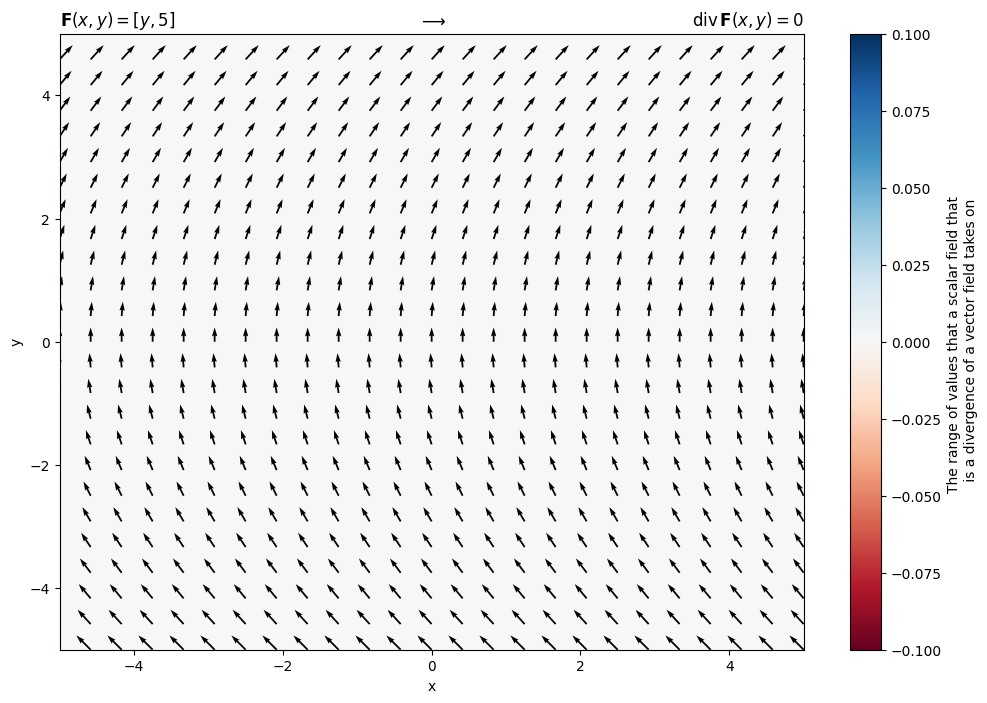

In [7]:
F = ['y', '5']
divergence_plot(F)

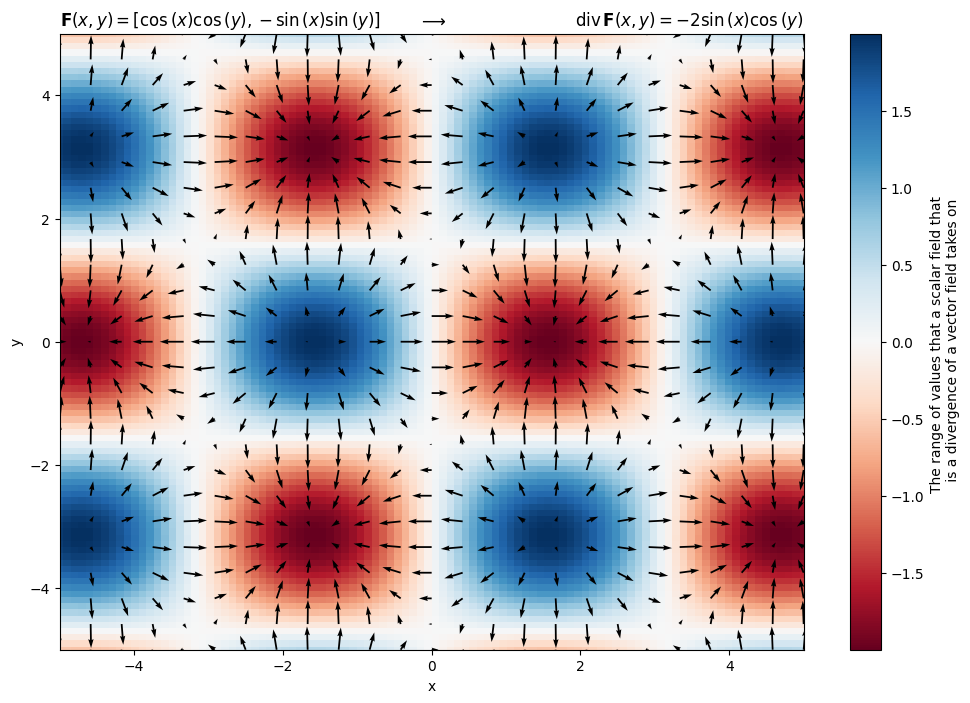

In [8]:
F = ['cos(x)*cos(y)', '-sin(x)*sin(y)']
divergence_plot(F)

---
### **Curl**

In a nutshell: The non-zero value of rotation is an illustration of the fact that there are vortices in the space described by the vector function. Fields with zero rotation are called vortexless fields.

$ \operatorname{curl}\mathbf{F}(x,y,z)
= \begin{bmatrix}\frac{\partial}{\partial x} \\ \frac{\partial}{\partial y} \\ \frac{\partial}{\partial z} \end{bmatrix} \times \mathbf{F}(x,y,z)$

$ \operatorname{curl}\mathbf{F}(x,y,z)
= \begin{bmatrix}\frac{\partial}{\partial x} \\ \frac{\partial}{\partial y} \\ \frac{\partial}{\partial z} \end{bmatrix} \times \begin{bmatrix}F_x(x,y,z) \\ F_y(x,y,z) \\ F_z(x,y,z)\end{bmatrix}$

$\operatorname{curl}\mathbf{F}(x,y,z)
= \begin{vmatrix} \mathbf i & \mathbf j & \mathbf k \\ \frac{\partial}{\partial x} & \frac{\partial}{\partial y} & \frac{\partial}{\partial z} \\ F_x(x,y,z) & F_y(x,y,z) & F_z(x,y,z) \end{vmatrix}; \;
\mathbf i = \begin{bmatrix} 1\\0\\0\end{bmatrix},\; \mathbf j=\begin{bmatrix} 0\\1\\0 \end{bmatrix},\;\mathbf k= \begin{bmatrix} 0\\0\\1 \end{bmatrix}$

$\operatorname{curl}\mathbf{F}(x,y,z)
= \begin{bmatrix} \frac{\partial F_z}{\partial y} - \frac{\partial F_y}{\partial z} \\ \frac{\partial F_x}{\partial z} - \frac{\partial F_z}{\partial x} \\ \frac{\partial F_y}{\partial x} - \frac{\partial F_x}{\partial y} \end{bmatrix}$

In [9]:
def curl_plot(vector_field):
   
    # Definition of variables for SymPy library functions
    x, y = symbols('x y')
    
    # Calculation of the divergence of the vector field F(x, y)
    Fx = sympify(vector_field[0])
    Fy = sympify(vector_field[1])
    curlF = diff(Fy, x) - diff(Fx, y)
    
    # Determine the size of the chart and add titles
    plt.figure(figsize = (12, 8))
    plt.title(r'$\mathbf{F}(x,y) = $' + f'$[{latex(Fx)}, {latex(Fy)}]$', loc = 'left')
    plt.title(r'$\longrightarrow$', loc = 'center')
    plt.title(r'$\operatorname{curl}\mathbf{F}(x,y,z) = $' + f'$[0, 0, {latex(curlF)}]$', loc = 'right')
    
    # Create a function based on SymPy mathematical formulas
    Fx = lambdify([x, y], Fx)
    Fy = lambdify([x, y], Fy)
    curlF = lambdify([x, y], curlF)
     
    # Define a grid to visualize the vector field curlF(x, y)
    vector_density = 50
    dx_mesh, dy_mesh = np.meshgrid(np.linspace(-5, 5, vector_density), 
                                   np.linspace(-5, 5, vector_density))    
    
    # Visualization of the vector field curlF(x, y)
    try:
        curlF_max = np.array(curlF(dx_mesh, dy_mesh)).max()
        curlF_min = np.array(curlF(dx_mesh, dy_mesh)).min()
        plt.scatter(dx_mesh, dy_mesh, s = 10, c = curlF(dx_mesh, dy_mesh),
                    cmap = 'RdBu', 
                    norm = clr.TwoSlopeNorm(vmin = curlF_min, 
                                            vcenter = 0.00, 
                                            vmax = curlF_max))
    except:
        curlF_const = np.full((vector_density, vector_density), curlF(dx_mesh, dy_mesh))
        plt.scatter(dx_mesh, dy_mesh, s = 10, c = curlF_const, 
                    cmap = 'RdBu', 
                    norm = clr.TwoSlopeNorm(vcenter = 0.00))
        
    plt.colorbar().set_label('Color visualization of the return and length of the vector - coordinate `z` \n Red color: ⨂ | Blue color: ⨀',
                             rotation = 90)
 
    # Re-define a grid to visualize the vector field F(x, y)
    vector_density = 25
    dx_mesh, dy_mesh = np.meshgrid(np.linspace(-5, 5, vector_density),
                                   np.linspace(-5, 5, vector_density))   
    
    # Visualization of the vector field F(x, y)
    plt.quiver(dx_mesh, dy_mesh, Fx(dx_mesh, dy_mesh), Fy(dx_mesh, dy_mesh))
    
    # Add other chart parameters
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.xlabel('x')
    plt.ylabel('y')
    
    # Chart display
    return plt.show()

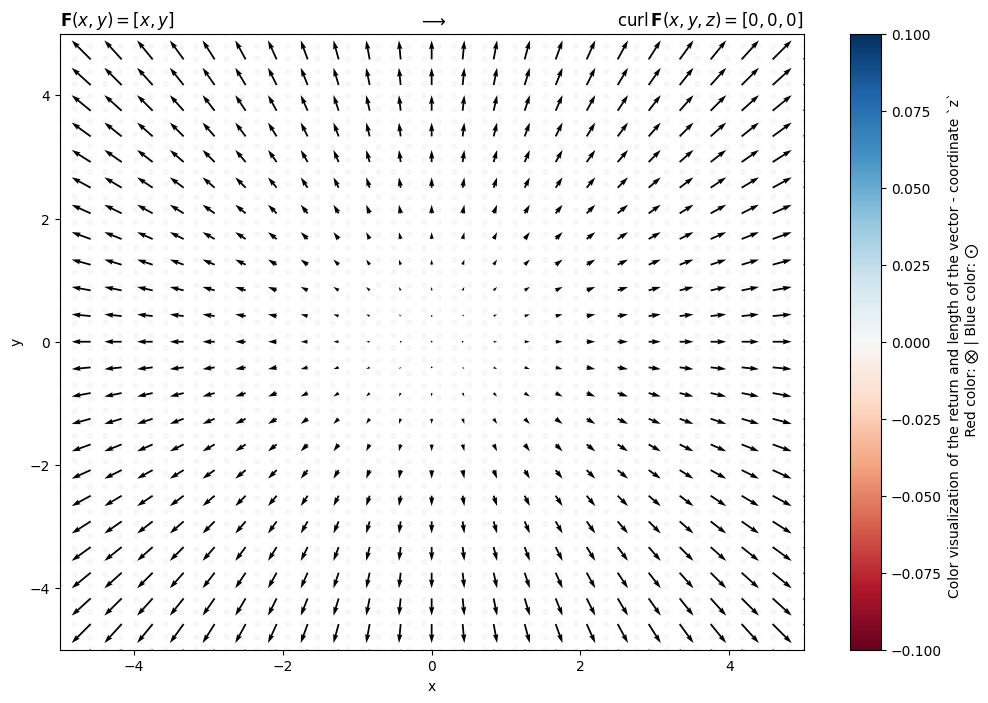

In [10]:
F = ['x', 'y']
curl_plot(F)

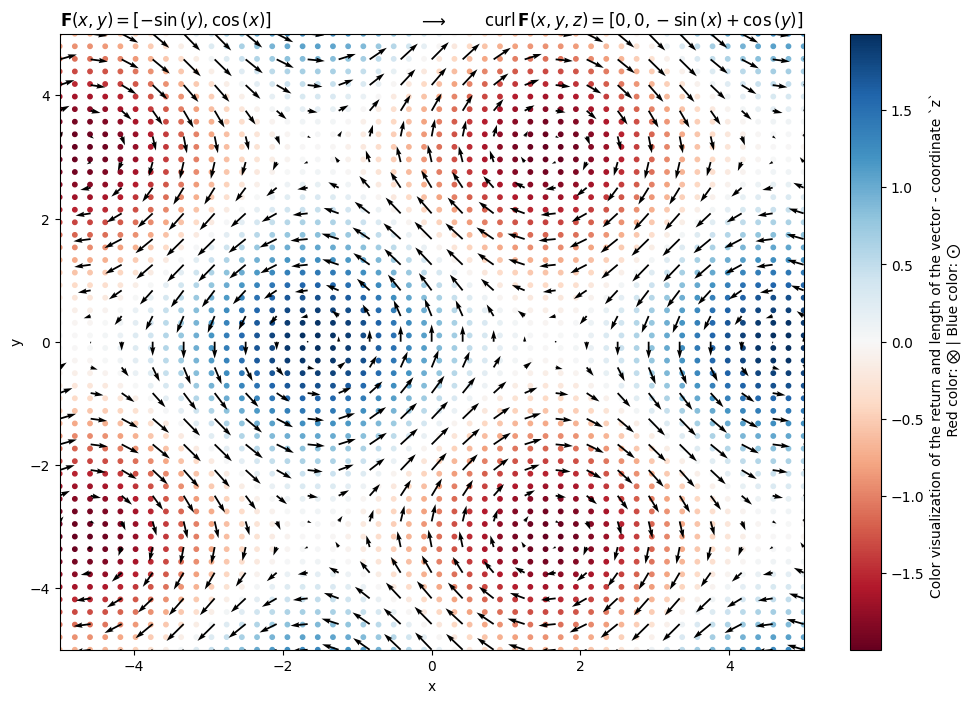

In [11]:
F = ['-sin(y)', 'cos(x)']
curl_plot(F)